In [ ]:
import pandas as pd
from utils import load_data

import matplotlib.pyplot as plt

In [ ]:
mmgbsa, top_k_mmgbsa, mmgbsa_source = load_data(f"results/mcl1_mmpbsa_gb_proto_shuffled.sqlite", k_ratio=0.01)
vina, top_k_vina, vina_source = load_data(f"results/mcl1_vina_proto_shuffled.sqlite", k_ratio=0.01)
vina_source = vina_source.drop(columns=["Unnamed: 0"])
vina_source["method"] = "Docking"
mmgbsa_source["method"] = "MMGBSA"

df = pd.concat([mmgbsa_source, vina_source], ignore_index=True)
df = df.sort_values(by="name")
df = df.set_index("name")

Let's also load the experimental values and compare to them

In [ ]:
from rdkit import Chem
docking_experimental = pd.read_csv("../docking/experimental_docking_results.csv", names=["smiles_a", "smiles_b", "target"])
mmgbsa_experimental = pd.read_csv("../data/benchmark_dg_en_gb_avg.csv")

mmgbsa_experimental["smiles_canon"] = mmgbsa_experimental["smiles"].map(Chem.MolFromSmiles).map(Chem.MolToSmiles)

experimental = mmgbsa_experimental.merge(docking_experimental, left_on="smiles_canon", right_on="smiles_a", suffixes=["_mmgbsa", "_docking"])
experimental = experimental.drop(columns=["smiles", "smiles_a", "smiles_b", "smiles_canon", "name"])

We plot the top-1% of molecules for both MMGBSA and Docking

In [34]:
top1_docking_full = df[df["method"] == "Docking"].nsmallest(593, ["target"])
top1_mmgbsa_full = df[df["method"] == "MMGBSA"].nsmallest(593, ["target"])

overlap = top1_docking_full.index.intersection(top1_mmgbsa_full.index)

top1_docking = top1_docking_full.drop(overlap)
top1_mmgbsa = top1_mmgbsa_full.drop(overlap)

# We need both docking and mmgbsa values
top1_docking = df.loc[top1_docking.index].pivot(columns=["method"], values=["target"])
top1_mmgbsa = df.loc[top1_mmgbsa.index].pivot(columns=["method"], values=["target"])
top1_overlap = df.loc[overlap].pivot(columns=["method"], values=["target"])

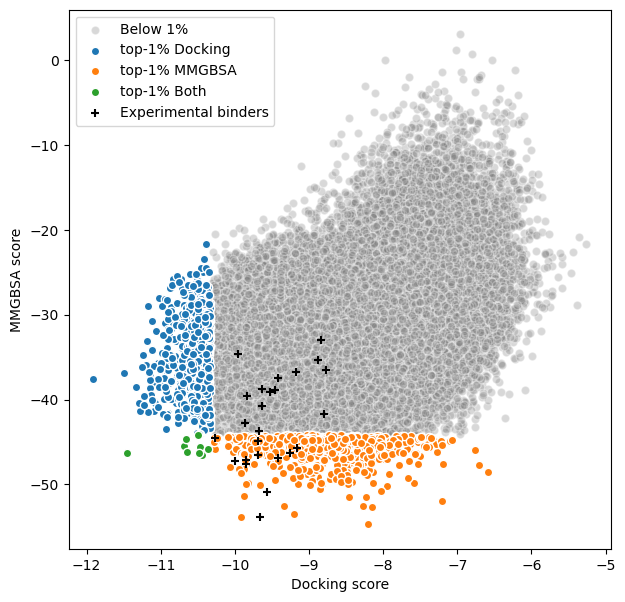

In [35]:
pivot_df = df.pivot(columns=["method"], values=["target"])

plt.scatter(pivot_df[("target", "Docking")], pivot_df[("target", "MMGBSA")], edgecolor="white", color="grey", alpha=0.3, label="Below 1%")

plt.scatter(top1_docking[("target", "Docking")], top1_docking[("target", "MMGBSA")], label="top-1% Docking", edgecolor="white")
plt.scatter(top1_mmgbsa[("target", "Docking")], top1_mmgbsa[("target", "MMGBSA")], label="top-1% MMGBSA", edgecolor="white")
plt.scatter(top1_overlap[("target", "Docking")], top1_overlap[("target", "MMGBSA")], label="top-1% Both", edgecolor="white")

plt.scatter(experimental["target_docking"], experimental["target_mmgbsa"], marker="+", label="Experimental binders", color="k")
plt.xlabel("Docking score")
plt.ylabel("MMGBSA score")
plt.legend()
plt.gcf().set_size_inches(7, 7)
plt.savefig("figures/docking_vs_mmgbsa_top1.png", dpi=300, bbox_inches="tight")

In [ ]:
combined = pd.concat(
    [pivot_df, top1_docking, top1_mmgbsa, top1_overlap],
    keys=["Below 1%", "Docking 1%", "MMGBSA 1%", "Overlap 1%"]
).droplevel(level=0, axis=1).reset_index().rename(columns={"level_0": "Subset"})

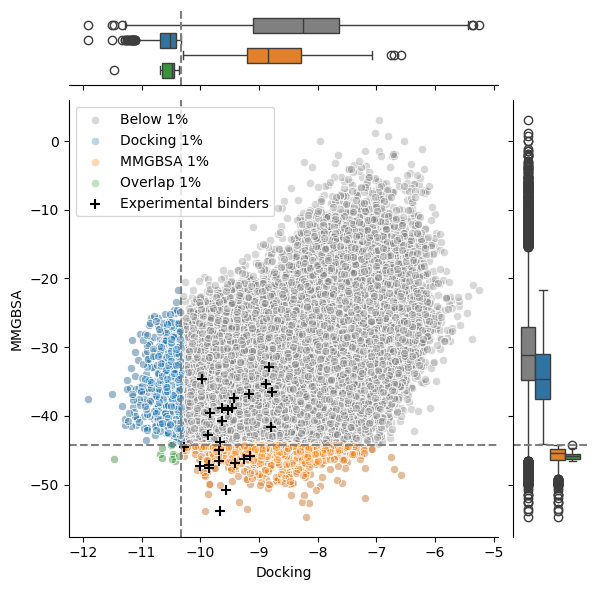

In [72]:
from matplotlib.colors import to_rgba
import seaborn as sns

color_dict = {
    "Below 1%": to_rgba("grey", 0.3),
    "Docking 1%": to_rgba("tab:blue", 0.3),
    "MMGBSA 1%": to_rgba("tab:orange", 0.3),
    "Overlap 1%": to_rgba("tab:green", 0.3),
}

markers = {
    "Below 1%": "o",
    "Docking 1%": "o",
    "MMGBSA 1%": "o",
    "Overlap 1%": "o",
}


g = sns.JointGrid(data=combined, x="Docking", y="MMGBSA", hue="Subset")

for name, group in combined.groupby("Subset"):

    if name != "Retrieved":
        sns.scatterplot(
            group, x="Docking", y="MMGBSA", marker=markers[name], ec="white", fc=color_dict[name], ax=g.ax_joint, label=name
        )
    else:
        sns.scatterplot(
            group, x="Docking", y="MMGBSA", marker=markers[name], color=color_dict[name], ax=g.ax_joint, label=name
        )


sns.scatterplot(experimental, x="target_docking", y="target_mmgbsa", color="k", label="Experimental binders", ax=g.ax_joint, marker="+", s=50, linewidth=1.5)

horder = sorted(combined["Subset"].unique())
sns.boxplot(combined, x="Docking", hue="Subset", ax=g.ax_marg_x, legend=False, palette=color_dict, hue_order=horder)
sns.boxplot(combined, y="MMGBSA", hue="Subset", ax=g.ax_marg_y, legend=False, palette=color_dict, hue_order=horder)

g.refline(x=top1_docking_full.max()["target"], y=top1_mmgbsa_full.max()["target"])

g.figure.savefig("figures/docking_vs_mmgbsa_top1.png", dpi=300, bbox_inches="tight")

In [36]:
len(overlap) / 593 * 100

1.6863406408094435

We will now investigate how many of the top-1% of MMGBSA scores we actually find when we optimize on the docking scores.

In [53]:
import pandas as pd
from utils import load_data

db = "mcl1_vina_proto_shuffled.sqlite"
db_batch = f"mcl1_vina_proto_batch.sqlite"
MOLS_PER_ITER = 600

data_batch, top_k_batch, source = load_data(f"results/{db_batch}", k_ratio=0.01)
data, top_k, source = load_data(f"results/{db}", k_ratio=0.01)
assert (top_k_batch == top_k).all().all()
K = len(top_k)
data_batch["Surrogate"] = (data_batch["Surrogate"] + " (B)")
data_batch["Iteration"] *= MOLS_PER_ITER
data["Scenario"] = "Sequential"
data_batch["Scenario"] = "Batched"
data_batch["experiment_id"] = data_batch["experiment_id"] + data["experiment_id"].max()  # Start all from 0
results_df = pd.concat([data, data_batch], ignore_index=True)

In [54]:
linear_models_docking = results_df[
    (results_df["Embedding Model"].isin(["ChemBERTa-2", "MolFormer"])) & (results_df["Surrogate"] == "Linear")
]

linear_models_docking.shape

(7202, 31)

In [57]:
linear_models_docking = linear_models_docking.assign(
    is_top_k_mmgbsa=linear_models_docking["molecule"].isin(top1_mmgbsa_full["smiles"])
)

In [61]:
linear_models_docking.groupby(["Embedding Model"])["is_top_k_mmgbsa"].sum()

Embedding Model
ChemBERTa-2    39
MolFormer      40
Name: is_top_k_mmgbsa, dtype: int64

In [62]:
linear_models_docking.groupby(["Embedding Model"])["is_top_k"].sum()

Embedding Model
ChemBERTa-2    576
MolFormer      568
Name: is_top_k, dtype: int64

In [59]:
# Found when running Active Learning on docking scores
found = df[df["smiles"].isin(linear_models_docking["molecule"])]
pivot_found = found.pivot(columns=["method"], values=["target"])
pivot_found = pivot_found.droplevel(level=0, axis=1).reset_index(drop=True)[["Docking", "MMGBSA"]]
pivot_found["Subset"] = "Retrieved"

In [62]:
pivot_found

method,Docking,MMGBSA,Subset
0,-6.334,-18.853633,Retrieved
1,-6.897,-6.306912,Retrieved
2,-7.232,-22.560601,Retrieved
3,-7.423,-14.651623,Retrieved
4,-8.196,-27.666446,Retrieved
...,...,...,...
4428,-9.395,-25.610251,Retrieved
4429,-10.146,-29.449601,Retrieved
4430,-9.599,-33.959154,Retrieved
4431,-9.477,-27.172166,Retrieved


In [67]:
combined_with_retrieved = pd.concat([combined[["Subset", "Docking", "MMGBSA"]], pivot_found], axis=0, ignore_index=True)

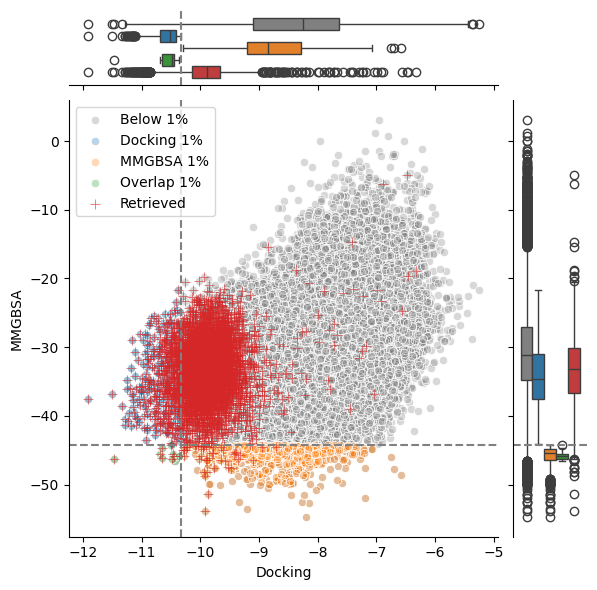

In [71]:
color_dict = {
    "Below 1%": to_rgba("grey", 0.3),
    "Docking 1%": to_rgba("tab:blue", 0.3),
    "MMGBSA 1%": to_rgba("tab:orange", 0.3),
    "Overlap 1%": to_rgba("tab:green", 0.3),
    "Retrieved": to_rgba("tab:red", 0.7)
}

markers = {
    "Below 1%": "o",
    "Docking 1%": "o",
    "MMGBSA 1%": "o",
    "Overlap 1%": "o",
    "Retrieved": "+"
}


g = sns.JointGrid(data=combined_with_retrieved, x="Docking", y="MMGBSA", hue="Subset")

for name, group in combined_with_retrieved.groupby("Subset"):

    if name != "Retrieved":
        sns.scatterplot(
            group, x="Docking", y="MMGBSA", marker=markers[name], ec="white", fc=color_dict[name], ax=g.ax_joint, label=name
        )
    else:
        sns.scatterplot(
            group, x="Docking", y="MMGBSA", marker=markers[name], color=color_dict[name], ax=g.ax_joint, label=name, s=50
        )


# sns.scatterplot(experimental, x="target_docking", y="target_mmgbsa", color="k", label="Experimental binders", ax=g.ax_joint, marker="+", s=50, linewidth=1.5)

horder = sorted(combined_with_retrieved["Subset"].unique())
sns.boxplot(combined_with_retrieved, x="Docking", hue="Subset", ax=g.ax_marg_x, legend=False, palette=color_dict, hue_order=horder)
sns.boxplot(combined_with_retrieved, y="MMGBSA", hue="Subset", ax=g.ax_marg_y, legend=False, palette=color_dict, hue_order=horder)

g.refline(x=top1_docking_full.max()["target"], y=top1_mmgbsa_full.max()["target"])